In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


/kaggle/input/train.csv
/kaggle/input/test.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/sample_submission.csv.zip
/kaggle/input/tweet-sentiment-extraction/train.csv
/kaggle/input/tweet-sentiment-extraction/test.csv
/kaggle/input/tweet-sentiment-extraction/description.md
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv
/kaggle/input/tweet-sentiment-extraction/train.csv.zip
/kaggle/input/tweet-sentiment-extraction/test.csv.zip
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv.zip


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt


2026-01-07 01:20:17.941137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767748817.955205      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767748817.959571      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 01:20:17.977770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
#!pip install -U keras-tuner


In [4]:
data = pd.read_csv("../input/tweet-sentiment-extraction/train.csv")


In [5]:
data.head()


,textID,text,selected_text,sentiment
0,8d4ad58b45,eating breakfast getting ready to go to schoo...,eating breakfast getting ready to go to schoo...,negative
1,fdfe12a800,Going to fold laundry and then hit the sack. I...,I have boring saturday evenings,negative
2,5efd224f4e,happy mothers day to all im off to spend the...,happy,positive
3,5678f1f769,one of my favorite quotes ever,favorite,positive
4,706510b794,"yeah, that was my point >.< please dont make ...",worse,negative


In [6]:
print(len(data.text), len(data.textID))


24732 24732


In [7]:
data.text[data.textID == "a88287bbda"]


21524      i`m sorry people are so rude to you, isaac, ...
Name: text, dtype: object

In [8]:
print(len(data.text), len(data.textID))


24732 24732


In [9]:
sum(data.text.str.startswith("http"))


nan

In [10]:
data.text[24]


'i wanna move back to Pennsylvania'

In [11]:
data.text[data.textID == "a88287bbda"]


21524      i`m sorry people are so rude to you, isaac, ...
Name: text, dtype: object

In [12]:
len(data['text'])


24732

In [13]:
import string
import re

def clean_text(dataset, field):
    print(len(dataset[field]))
    for index, strin in enumerate(dataset[field]):
        if not strin:
            strin = strin.lower()
            strin = strin.replace("'", "")
            strin = strin.replace("\n", "")
            strin = strin.strip()
            strin = re.sub(r'^https?:\/\/.*[\r\n]*', '', strin)
            strin = strin.replace('[{}]'.format(string.punctuation), '')
            dataset[field][index] = strin


clean_text(data, 'text')
clean_text(data, 'selected_text')


24732
24732


In [14]:
print(len(data.text), len(data.textID))


24732 24732


In [15]:
data.text[24]


'i wanna move back to Pennsylvania'

In [16]:
len(data.text)


24732

In [17]:
len(data.textID)


24732

In [18]:
data.text[data.textID == "a88287bbda"]


21524      i`m sorry people are so rude to you, isaac, ...
Name: text, dtype: object

In [19]:
data = data[pd.notnull(data.selected_text)]


In [20]:
print(data.text[data.textID == "a88287bbda"])
print(len(data.text), len(data.textID))


21524      i`m sorry people are so rude to you, isaac, ...
Name: text, dtype: object
24731 24731


In [21]:
from sklearn.model_selection import train_test_split

train, validation = train_test_split(data, test_size = 0.25)
print(len(data), len(train), len(validation))


24731 18548 6183


In [22]:
train


,textID,text,selected_text,sentiment
4452,5162aa68ce,after show at our house rocked! saying goodbye...,after show at our house rocked! saying goodbye...,neutral
2788,c58dce817e,"mmm, athletic!!","mmm, athletic!!",neutral
16595,e9f7f78cfa,mcfly gig last nightt omg it was amazin didnt ...,it was amazin,positive
9265,f1412f1467,I`m really nervous about giving a speech at a ...,I`m really nervous ab,negative
6842,4aeeea3442,Mexican! That`s what I`m craving,Mexican! That`s what I`m craving,neutral
...,...,...,...,...
22800,57d8d754d3,Finally a Black Disney princess.,Finally,positive
20136,52ca74468a,We`re idiots. Ok mostly I was skint but he...,re idiot,negative
1860,b749c20598,"Sometimes after a long weekend, you just need ...",good conversation. thanks bro,positive
10933,07e2afe564,"Yep, I do.","Yep, I do.",neutral


In [23]:
validation.head()


,textID,text,selected_text,sentiment
18258,e53ebf4ee2,"oh wait, i messed up my own messed up lyrics,...",messed,negative
1033,c3bb37493e,http://twitpic.com/4jerc view of Atlas Mountai...,http://twitpic.com/4jerc view of Atlas Mountai...,neutral
2429,c520623bcb,Haha! Sometimes mobiles makes us slaves ... b...,Haha! Sometimes mobiles makes us slaves ... bu...,neutral
21260,037e4d6cc0,not really in the twitter mood today... i don`...,not really in the twitter mood today... i don`...,neutral
21006,e0a3f84256,You are welcome.,You are welcome.,positive


In [24]:
print(train.text[train.textID == "a88287bbda"])


21524      i`m sorry people are so rude to you, isaac, ...
Name: text, dtype: object


In [25]:
list(data.text[data.textID == "a88287bbda"])


['  i`m sorry people are so rude to you, isaac, they should get some manners and know better than to be so lewd!']

In [26]:
vocab_size = 10000
embedding_dim = 16
max_length = 50
trunc_type='post'
pad_type='post'
oov_tok = ""

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train.text)
word_index = tokenizer.word_index


In [27]:
word_index


{'': 1,
 'i': 2,
 'to': 3,
 'the': 4,
 'a': 5,
 'my': 6,
 'it': 7,
 'you': 8,
 'and': 9,
 'is': 10,
 'in': 11,
 's': 12,
 'for': 13,
 'of': 14,
 't': 15,
 'that': 16,
 'on': 17,
 'me': 18,
 'so': 19,
 'have': 20,
 'but': 21,
 'm': 22,
 'just': 23,
 'with': 24,
 'day': 25,
 'be': 26,
 'not': 27,
 'at': 28,
 'was': 29,
 'now': 30,
 'all': 31,
 'good': 32,
 'can': 33,
 'this': 34,
 'up': 35,
 'out': 36,
 'get': 37,
 'are': 38,
 'no': 39,
 'like': 40,
 'go': 41,
 'http': 42,
 'your': 43,
 'work': 44,
 'today': 45,
 'do': 46,
 'too': 47,
 'going': 48,
 'love': 49,
 'got': 50,
 'lol': 51,
 'we': 52,
 'from': 53,
 'what': 54,
 'time': 55,
 'one': 56,
 'u': 57,
 'there': 58,
 'happy': 59,
 'back': 60,
 'really': 61,
 'com': 62,
 'know': 63,
 'will': 64,
 'don': 65,
 'im': 66,
 'about': 67,
 'am': 68,
 'its': 69,
 'some': 70,
 'had': 71,
 'they': 72,
 'see': 73,
 'new': 74,
 'night': 75,
 'if': 76,
 'want': 77,
 'well': 78,
 'how': 79,
 '2': 80,
 'think': 81,
 'home': 82,
 'when': 83,
 'll': 84

In [28]:
training_sequences = tokenizer.texts_to_sequences(np.array(train.text))
training_padded = pad_sequences(training_sequences,truncating=trunc_type, padding=pad_type)

max_length = len(training_padded[0])

validation_sequences = tokenizer.texts_to_sequences(np.array(validation.text))
validation_padded = pad_sequences(validation_sequences, padding=pad_type, maxlen = max_length)


In [29]:
training_selected_sequences = tokenizer.texts_to_sequences(np.array(train.selected_text))
validation_selected_sequences = tokenizer.texts_to_sequences(np.array(validation.selected_text))


In [30]:
training_padded[4]


array([2646,   16,   12,   54,    2,   22, 1347,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
      dtype=int32)

In [31]:
training_selected_sequences[4]


[2646, 16, 12, 54, 2, 22, 1347]

In [32]:
def get_list(padded, sequence):
    return np.array([1 if x in sequence else 0 for x in padded])


In [33]:
get_list(training_padded[4], training_selected_sequences[4])


array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [34]:
train_y = np.array([get_list(i,j) for i,j in zip(training_padded, training_selected_sequences)])
validate_y = np.array([get_list(i,j) for i,j in zip(validation_padded, validation_selected_sequences)])


In [35]:
train_y


array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])

In [36]:
np.array(train.sentiment).shape


(18548,)

In [37]:
training_padded.shape


(18548, 33)

In [38]:
rev_word_index = {v: k for k, v in word_index.items()}


In [39]:
def get_phrase(index): 
    return np.array([rev_word_index[i] for i in train_x[index][train_y.astype(bool)[index]]])


In [40]:
train_x = np.copy(training_padded)
validate_x = np.copy(validation_padded)


In [41]:
len(np.array(train.sentiment))


18548

In [42]:
len(training_padded)


18548

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

# model = Sequential()
# model.add(Embedding(vocab_size, 16, input_length=max_length))
# model.add(tf.keras.layers.GlobalAveragePooling1D())
# model.add(Dropout(0.5)),
# model.add(Dense(max_length * 2, activation='relu'))
# model.add(Dense(max_length, activation='softmax'))
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# history = model.fit(train_x, train_y, epochs=20, verbose=2,
#                    validation_data = (validate_x, validate_y))


In [44]:
plt.style.use('dark_background')

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()
  
# plot_graphs(history, "accuracy")
# plot_graphs(history, "loss")


In [45]:
#training_selected_sequences


In [46]:
#len(training_selected_sequences)


In [47]:
# sel_sequences_train = np.zeros((len(training_selected_sequences), vocab_size))
# for index, sentence in enumerate(training_selected_sequences):
#     for word in sentence:
#         sel_sequences_train[index][word] = 1
        
# sel_sequences_val = np.zeros((len(validation_selected_sequences), vocab_size))
# for index, sentence in enumerate(validation_selected_sequences):
#     for word in sentence:
#         sel_sequences_val[index][word] = 1


In [48]:
#sel_sequences_val.shape


In [49]:
# from kerastuner.tuners import RandomSearch

# def build_model(hp): 
#     model = Sequential()
#     model.add(Embedding(vocab_size, output_dim=hp.Int('units',
#                                         min_value=16,
#                                         max_value=512,
#                                         step=100), input_length=max_length))
#     model.add(Bidirectional(tf.keras.layers.GRU(32)))
#     model.add(Dense(vocab_size, activation='softmax'))
#     model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate',
#                       values=[1e-2, 1e-3, 1e-4])), metrics=['accuracy'])
#     return model
              
# tuner = RandomSearch(
#     build_model,
#     objective='val_accuracy',
#     max_trials=5,
#     executions_per_trial=3)
              
# tuner.search(train_x, sel_sequences_train, epochs=20, verbose = 2,
#                    validation_data = (validate_x, sel_sequences_val))


In [50]:
print(training_padded[(train.sentiment == "positive")].shape)
print(training_padded[(train.sentiment == "neutral")].shape)
training_padded[(train.sentiment == "negative")].shape


(5797, 33)
(7465, 33)


(5286, 33)

In [51]:
train_positive_x = training_padded[(train.sentiment == "positive")]
train_neutral_x = training_padded[(train.sentiment == "neutral")]
train_negative_x = training_padded[(train.sentiment == "negative")]
train_positive_y = train_y[(train.sentiment == "positive")]
train_neutral_y = train_y[(train.sentiment == "neutral")]
train_negative_y = train_y[(train.sentiment == "negative")]

validate_positive_x = validation_padded[(validation.sentiment == "positive")]
validate_neutral_x = validation_padded[(validation.sentiment == "neutral")]
validate_negative_x = validation_padded[(validation.sentiment == "negative")]
validate_positive_y = validate_y[(validation.sentiment == "positive")]
validate_neutral_y = validate_y[(validation.sentiment == "neutral")]
validate_negative_y = validate_y[(validation.sentiment == "negative")]


In [52]:
l = tf.keras.losses.BinaryCrossentropy(from_logits=True)


In [53]:
positive_model = Sequential()
positive_model.add(Embedding(vocab_size, 16, input_length=max_length))
positive_model.add(Dropout(0.5))
positive_model.add(Bidirectional(LSTM(20)))
positive_model.add(Dropout(0.5))
positive_model.add(Dense(max_length, activation='softmax'))
positive_model.compile(loss=l, optimizer=tf.keras.optimizers.Adam(0.001), metrics=['accuracy'])
positive_history = positive_model.fit(train_positive_x.astype(float), train_positive_y.astype(float), epochs=40, verbose=2,
                   validation_data = (validate_positive_x.astype(float), validate_positive_y.astype(float)))


Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-01-07 01:20:30.876185: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767748830.876654      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 40095 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6
/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:780: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1767748833.521693      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


182/182 - 4s - 22ms/step - accuracy: 0.1320 - loss: 0.3950 - val_accuracy: 0.2198 - val_loss: 0.2815
Epoch 2/40
182/182 - 1s - 5ms/step - accuracy: 0.1647 - loss: 0.2952 - val_accuracy: 0.2616 - val_loss: 0.2641
Epoch 3/40
182/182 - 1s - 5ms/step - accuracy: 0.1742 - loss: 0.2805 - val_accuracy: 0.3658 - val_loss: 0.2603
Epoch 4/40
182/182 - 1s - 5ms/step - accuracy: 0.1885 - loss: 0.2678 - val_accuracy: 0.3473 - val_loss: 0.2555
Epoch 5/40
182/182 - 1s - 5ms/step - accuracy: 0.2022 - loss: 0.2569 - val_accuracy: 0.3318 - val_loss: 0.2591
Epoch 6/40
182/182 - 1s - 5ms/step - accuracy: 0.2124 - loss: 0.2513 - val_accuracy: 0.3437 - val_loss: 0.2601
Epoch 7/40
182/182 - 1s - 5ms/step - accuracy: 0.2211 - loss: 0.2433 - val_accuracy: 0.3271 - val_loss: 0.2600
Epoch 8/40
182/182 - 1s - 5ms/step - accuracy: 0.2356 - loss: 0.2379 - val_accuracy: 0.3271 - val_loss: 0.2618
Epoch 9/40
182/182 - 1s - 5ms/step - accuracy: 0.2501 - loss: 0.2333 - val_accuracy: 0.3173 - val_loss: 0.2609
Epoch 10/40

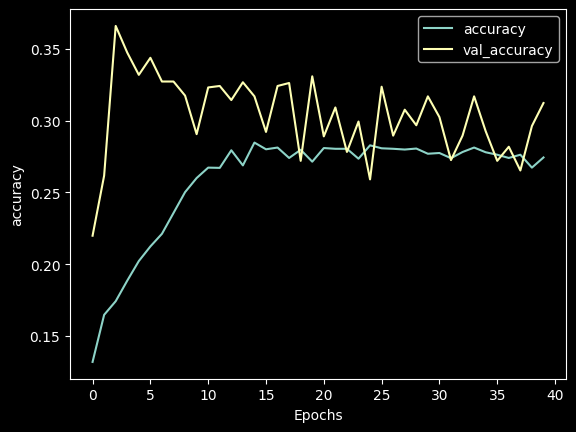

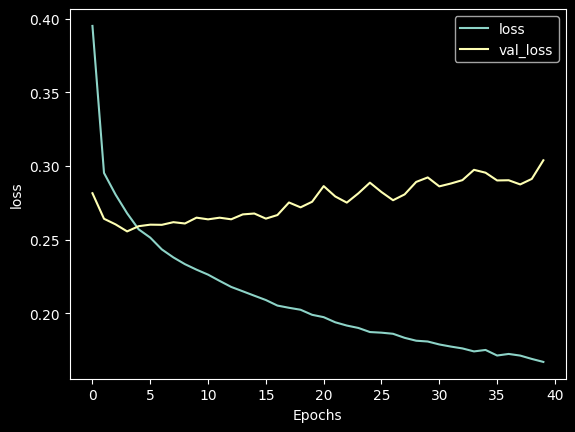

In [54]:
plot_graphs(positive_history, "accuracy")
plot_graphs(positive_history, "loss")


In [55]:
# neutral_model = Sequential()
# neutral_model.add(Embedding(vocab_size, 16, input_length=max_length))
# neutral_model.add(Bidirectional(tf.keras.layers.GRU(32)))
# neutral_model.add(Dropout(0.5))
# neutral_model.add(Dense(max_length, activation='sigmoid'))
# neutral_model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(0.001), metrics=['accuracy'])
# neutral_history = neutral_model.fit(train_neutral_x, train_neutral_y, epochs=25, verbose=2,
#                    validation_data = (validate_neutral_x, validate_neutral_y))


In [56]:
# plot_graphs(neutral_history, "accuracy")
# plot_graphs(neutral_history, "loss")


In [57]:
print(train_negative_x.shape)
print(max_length)


(5286, 33)
33


In [58]:
negative_model = Sequential()
negative_model.add(Embedding(vocab_size, 16, input_length=max_length))
negative_model.add(Dropout(0.5))
negative_model.add(Bidirectional(LSTM(20)))
negative_model.add(Dropout(0.5))
negative_model.add(Dense(max_length, activation='softmax'))
negative_model.compile(loss=l, optimizer=tf.keras.optimizers.Adam(0.001), metrics=['accuracy'])
negative_history = negative_model.fit(train_negative_x, train_negative_y, epochs=40, verbose=2,
                   validation_data = (validate_negative_x, validate_negative_y))


Epoch 1/40
166/166 - 2s - 13ms/step - accuracy: 0.0944 - loss: 0.4256 - val_accuracy: 0.0905 - val_loss: 0.3059
Epoch 2/40
166/166 - 1s - 5ms/step - accuracy: 0.1182 - loss: 0.3224 - val_accuracy: 0.0776 - val_loss: 0.2909
Epoch 3/40
166/166 - 1s - 5ms/step - accuracy: 0.1048 - loss: 0.3059 - val_accuracy: 0.0771 - val_loss: 0.2844
Epoch 4/40
166/166 - 1s - 5ms/step - accuracy: 0.1052 - loss: 0.2917 - val_accuracy: 0.0695 - val_loss: 0.2842
Epoch 5/40
166/166 - 1s - 5ms/step - accuracy: 0.0997 - loss: 0.2806 - val_accuracy: 0.0765 - val_loss: 0.2861
Epoch 6/40
166/166 - 1s - 5ms/step - accuracy: 0.1061 - loss: 0.2697 - val_accuracy: 0.0765 - val_loss: 0.2884
Epoch 7/40
166/166 - 1s - 5ms/step - accuracy: 0.1071 - loss: 0.2618 - val_accuracy: 0.1080 - val_loss: 0.2863
Epoch 8/40
166/166 - 1s - 4ms/step - accuracy: 0.1065 - loss: 0.2551 - val_accuracy: 0.0864 - val_loss: 0.2977
Epoch 9/40
166/166 - 1s - 4ms/step - accuracy: 0.1054 - loss: 0.2507 - val_accuracy: 0.0823 - val_loss: 0.2875


In [59]:
train_negative_x.shape


(5286, 33)

In [60]:
train_negative_y[0].shape


(33,)

In [61]:
train_negative_y


array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

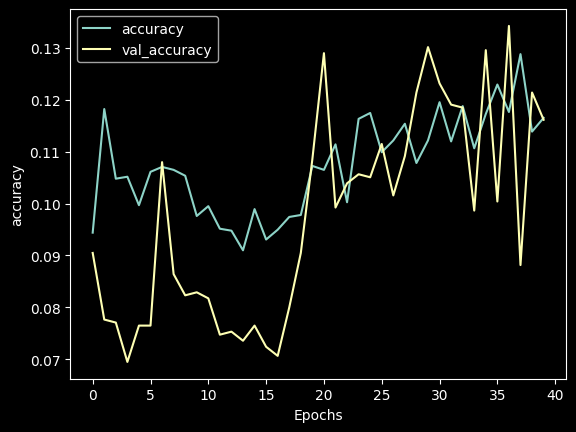

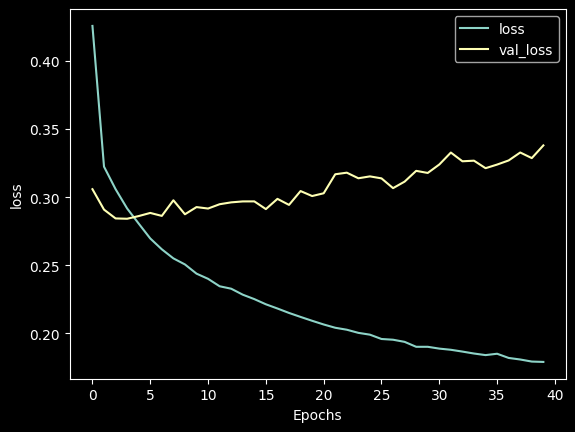

In [62]:
plot_graphs(negative_history, "accuracy")
plot_graphs(negative_history, "loss")


In [63]:
val_neg_preds = [np.round(negative_model.predict(item[np.newaxis])) for item in validate_negative_x]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

In [64]:
def check_negative(index):
    print(list(validation.text[validation.sentiment == "negative"])[index])
    print(get_phrase(validate_negative_x, np.array(val_neg_preds), index))
#np.array([rev_word_index[i] for i in array_x[index][array_y.astype(bool)[index]]])


In [65]:
check_negative(7)


@__SANDY i dont know! they sent out emails using my account about random stuff i didnt even understand i changed all my passwords


TypeError: get_phrase() takes 1 positional argument but 3 were given

In [66]:
validate_negative_x


array([[  92,  159,    2, ...,    0,    0,    0],
       [   6,   60,  372, ...,    0,    0,    0],
       [   1,  309,   58, ...,    0,    0,    0],
       ...,
       [ 377,  377,    1, ...,    0,    0,    0],
       [ 271,   30, 7617, ...,    0,    0,    0],
       [ 264,   10, 3709, ...,    0,    0,    0]], dtype=int32)

In [67]:
validate_negative_y


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

In [68]:
np.array(val_neg_preds)


array([[[0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)

In [69]:
test = pd.read_csv("../input/tweet-sentiment-extraction/test.csv")


In [70]:
test


,textID,text,sentiment
0,80a1e6bc32,I just saw a shooting star... I made my wish,positive
1,863097735d,gosh today sucks! i didnt get my tax returns! ...,negative
2,264cd5277f,tired and didn`t really have an exciting Satur...,neutral
3,baee1e6ffc,i`ve been eating cheetos all morning..,neutral
4,67d06a8dee,haiiii sankQ i`m fineee ima js get a checkup ...,neutral
...,...,...,...
2744,ec9796fa7a,"Gmorning ooh giirll, Mondays",positive
2745,7a23bb9610,p.s.: UV rays are just as strong with clouds ...,neutral
2746,22261e75c9,I`m so excited for Mothers Day! This has been...,positive
2747,b91c2995d0,I miss my 8703,negative


In [71]:
clean_text(test, 'text')


2749


In [72]:
test


,textID,text,sentiment
0,80a1e6bc32,I just saw a shooting star... I made my wish,positive
1,863097735d,gosh today sucks! i didnt get my tax returns! ...,negative
2,264cd5277f,tired and didn`t really have an exciting Satur...,neutral
3,baee1e6ffc,i`ve been eating cheetos all morning..,neutral
4,67d06a8dee,haiiii sankQ i`m fineee ima js get a checkup ...,neutral
...,...,...,...
2744,ec9796fa7a,"Gmorning ooh giirll, Mondays",positive
2745,7a23bb9610,p.s.: UV rays are just as strong with clouds ...,neutral
2746,22261e75c9,I`m so excited for Mothers Day! This has been...,positive
2747,b91c2995d0,I miss my 8703,negative


In [73]:
test_sequences = tokenizer.texts_to_sequences(np.array(test.text))
test_padded = pad_sequences(test_sequences,truncating=trunc_type, maxlen = max_length,padding=pad_type)


In [74]:
def get_phrase(array_x, array_y, index): 
    return np.array([rev_word_index[i] for i in array_x[index][array_y.astype(bool)[index]]])


In [75]:
for i,j in enumerate(validate_positive_y[:10]):
    print(get_phrase(validate_negative_x, validate_negative_y, i))


['messed' 'messed']
['really' 'bad']
['problem']
['boring']
['bad']
['fml']
['careless']
['i' 'i' 'didnt' 'even' 'understand' 'i']
['soooo' 'fed' 'up']
['' '']


In [76]:
test_padded[2].astype(bool).astype(int)[np.newaxis]


array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [77]:
preds = []
for index, item in enumerate(test_padded):
    if test.sentiment[index] == "positive":
        p = np.round(positive_model.predict(item[np.newaxis]))
        preds.append(p)
    elif test.sentiment[index] == "negative":
        p = np.round(negative_model.predict(item[np.newaxis]))
        preds.append(p)
    else:
        #p = np.round(neutral_model.predict(item[np.newaxis]))
        preds.append(test_padded[index].astype(bool).astype(int)[np.newaxis])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

In [78]:
preds


[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0.]], dtype=float32),
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0.]], dtype=float32),
 array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0.]], dtype=float32),
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.,

In [79]:
list(train.text)[3]


'I`m really nervous about giving a speech at a wedding tomorrow'

In [80]:
list(train.selected_text)[3]


'I`m really nervous ab'

In [81]:
list(train.sentiment)[3]


'negative'

In [82]:
data


,textID,text,selected_text,sentiment
0,8d4ad58b45,eating breakfast getting ready to go to schoo...,eating breakfast getting ready to go to schoo...,negative
1,fdfe12a800,Going to fold laundry and then hit the sack. I...,I have boring saturday evenings,negative
2,5efd224f4e,happy mothers day to all im off to spend the...,happy,positive
3,5678f1f769,one of my favorite quotes ever,favorite,positive
4,706510b794,"yeah, that was my point >.< please dont make ...",worse,negative
...,...,...,...,...
24727,7a659d6f9c,i love them,love,positive
24728,a841363ad3,"Oh, don`t spoil my fun, lol","Oh, don`t spoil my fun, lol",negative
24729,cb58dffb3d,should I still come? Its gonna be a while,should I still come? Its gonna be a while,neutral
24730,7be724bb6b,"For the record, john mayer is freaking cool.",john mayer is freaking cool.,positive


In [83]:
preds[0]


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.]], dtype=float32)

In [84]:
def get_phrase(array_x, array_y, index): 
    return np.array([rev_word_index[i] for i in array_x[index][array_y.astype(bool)[index][0]]if i != 0])


In [85]:
preds[2][0]


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [86]:
test_padded[2][np.array(preds).astype(bool)[2][0]]


array([201,   9, 147,  15,  61,  20,  95, 887, 455,  92,  78,  94,   7,
        12, 138, 112], dtype=int32)

In [87]:
[rev_word_index[i] for i in test_padded[2][np.array(preds).astype(bool)[2][0]] if i != 0]


['tired',
 'and',
 'didn',
 't',
 'really',
 'have',
 'an',
 'exciting',
 'saturday',
 'oh',
 'well',
 'hope',
 'it',
 's',
 'better',
 'tomorrow']

In [88]:
test["prediction"] = np.zeros(len(test))

for index, item in enumerate(preds):
    test['prediction'][index] = str(get_phrase(test_padded, np.array(preds), index))


/tmp/ipykernel_11/1657493341.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  test['prediction'][index] = str(get_phrase(test_padded, np.array(preds), index))
/tmp/ipykernel_11/1657493341.py:4: SettingWithCopyWarning: 
A value is trying t

In [89]:
test.prediction[test.sentiment == "neutral"] = test.text[test.sentiment == "neutral"]


In [90]:
test[test.sentiment=="neutral"]


,textID,text,sentiment,prediction
2,264cd5277f,tired and didn`t really have an exciting Satur...,neutral,tired and didn`t really have an exciting Satur...
3,baee1e6ffc,i`ve been eating cheetos all morning..,neutral,i`ve been eating cheetos all morning..
4,67d06a8dee,haiiii sankQ i`m fineee ima js get a checkup ...,neutral,haiiii sankQ i`m fineee ima js get a checkup ...
7,0f5c867e5d,In weho! They`re are playing a lot of brit,neutral,In weho! They`re are playing a lot of brit
8,02d47f1829,_NJ Oh! I`m only in my 7 I just joined Twitt...,neutral,_NJ Oh! I`m only in my 7 I just joined Twitt...
...,...,...,...,...
2740,19fa9c9eb4,_whacker skypeeeeee,neutral,_whacker skypeeeeee
2741,1dcb6fdb13,Why don`t adobe realise no one WANTS to pay fo...,neutral,Why don`t adobe realise no one WANTS to pay fo...
2742,7d574014bc,lol what!! where is it!,neutral,lol what!! where is it!
2743,c72e421fd4,Hey did you get any more info about your grad...,neutral,Hey did you get any more info about your grad...


In [91]:
test.prediction = test.prediction.str.replace("[", "")
test.prediction = test.prediction.str.replace("]", "")
test.prediction = test.prediction.str.replace("'", "")
test.prediction = test.prediction.str.replace("", "")


In [92]:
test[:25]


,textID,text,sentiment,prediction
0,80a1e6bc32,I just saw a shooting star... I made my wish,positive,
1,863097735d,gosh today sucks! i didnt get my tax returns! ...,negative,
2,264cd5277f,tired and didn`t really have an exciting Satur...,neutral,tired and didn`t really have an exciting Satur...
3,baee1e6ffc,i`ve been eating cheetos all morning..,neutral,i`ve been eating cheetos all morning..
4,67d06a8dee,haiiii sankQ i`m fineee ima js get a checkup ...,neutral,haiiii sankQ i`m fineee ima js get a checkup ...
5,7438c9c09a,CONGRATS on graduating college!,positive,congrats
6,77a6add433,"loved, but hated driving in pollution",positive,
7,0f5c867e5d,In weho! They`re are playing a lot of brit,neutral,In weho! They`re are playing a lot of brit
8,02d47f1829,_NJ Oh! I`m only in my 7 I just joined Twitt...,neutral,_NJ Oh! I`m only in my 7 I just joined Twitt...
9,7b46dad07f,awww wish I was there! Have a brew for me B!,positive,


In [93]:
evaluation = test.textID.copy().to_frame()


In [94]:
evaluation['selected_text'] = test['prediction']
evaluation


,textID,selected_text
0,80a1e6bc32,
1,863097735d,
2,264cd5277f,tired and didn`t really have an exciting Satur...
3,baee1e6ffc,i`ve been eating cheetos all morning..
4,67d06a8dee,haiiii sankQ i`m fineee ima js get a checkup ...
...,...,...
2744,ec9796fa7a,
2745,7a23bb9610,p.s.: UV rays are just as strong with clouds ...
2746,22261e75c9,
2747,b91c2995d0,


In [95]:
evaluation.to_csv("submission.csv", index=False)


In [96]:
test.text[34]


' I`ll believe it when I see it'

In [97]:
test.prediction[34]


''

In [98]:
data.text[56]


' I`m absolutely jealous as hell of Brenda'

In [99]:
data.selected_text[56]


'jealous'

In [100]:
data[:30]


,textID,text,selected_text,sentiment
0,8d4ad58b45,eating breakfast getting ready to go to schoo...,eating breakfast getting ready to go to schoo...,negative
1,fdfe12a800,Going to fold laundry and then hit the sack. I...,I have boring saturday evenings,negative
2,5efd224f4e,happy mothers day to all im off to spend the...,happy,positive
3,5678f1f769,one of my favorite quotes ever,favorite,positive
4,706510b794,"yeah, that was my point >.< please dont make ...",worse,negative
5,fa1385e537,He says he feels mama tucking him in at night...,. Tomorrow will be tough!,negative
6,1e515e4f8e,I hate being young,hate,negative
7,25ec5e89c3,not Pimm`s in a can?,not Pimm`s in a can?,neutral
8,7907ced082,I like the last part in your methodology.,like,positive
9,b8a6304e59,I wish I was laying in the sand listening to t...,I wish I,positive


In [101]:
train[train.sentiment == "neutral"]


,textID,text,selected_text,sentiment
4452,5162aa68ce,after show at our house rocked! saying goodbye...,after show at our house rocked! saying goodbye...,neutral
2788,c58dce817e,"mmm, athletic!!","mmm, athletic!!",neutral
6842,4aeeea3442,Mexican! That`s what I`m craving,Mexican! That`s what I`m craving,neutral
18580,f2e59ef473,I have been subtly replacing it with 'penetra...,I have been subtly replacing it with 'penetrat...,neutral
18934,f87ffde1b0,_mueller yes i love it its just a little bit ...,"yes i love it its just a little bit complicated,",neutral
...,...,...,...,...
10680,44e014008b,angels even though I`m probably not the third...,angels even though I`m probably not the third....,neutral
15642,3da86f9809,I`ve just realised - 400 FOLLOWERS! YAY! ****,I`ve just realised - 400 FOLLOWERS! YAY! ****,neutral
17958,12f8ea67d2,Are you still taking calls? We were next to t...,Are you still taking calls? We were next to ta...,neutral
10933,07e2afe564,"Yep, I do.","Yep, I do.",neutral


In [102]:
equals = [i==j for i,j in zip(train.text[train.sentiment == "neutral"], train.selected_text[train.sentiment == "neutral"])]


In [103]:
equals


[True,
 False,
 True,
 False,
 False,
 True,
 False,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 False,
 False,
 True,
 False,
 True,
 False,
 True,
 False,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 False,


In [104]:
len(train.text[train.sentiment == "neutral"])


7465

In [105]:
equals


[True,
 False,
 True,
 False,
 False,
 True,
 False,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 False,
 False,
 True,
 False,
 True,
 False,
 True,
 False,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 False,


In [106]:
list(train.selected_text[train.sentiment == "neutral"])[1] == list(train.text[train.sentiment == "neutral"])[1]


False

In [107]:
list(train.text[train.sentiment == "neutral"])[1]


' mmm, athletic!!'

In [108]:
list(train.selected_text[train.sentiment == "neutral"])[1]


'mmm, athletic!!'